In [8]:
import pandas as pd
import numpy as np
from scipy import stats

pd.set_option('display.float_format', lambda x: f'{x:0.4f}')

In [9]:
DATA_PATH = 'merged_monthly.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

y_name = 'Brent_USD_bbl'
x_names = ['US_Crude_Stocks_Total_kbbl', 'USD_Index', 'China_PMI_Manufacturing', 'GPR_Index']

print(df.shape)
df.head()

(199, 6)


,Date,Brent_USD_bbl,US_Crude_Stocks_Total_kbbl,USD_Index,China_PMI_Manufacturing,GPR_Index
0,2010-01-01,76.1700,1034898,92.4403,55.8000,91.5810
1,2010-02-01,73.7500,1047340,93.8867,52.0000,80.7254
2,2010-03-01,78.8300,1059993,93.1499,55.1000,74.1169
3,2010-04-01,84.8200,1066543,92.6391,55.7000,88.7616
4,2010-05-01,75.9500,1069176,95.5306,53.9000,88.9587


In [10]:
#Helper function: build ARDL design matrix+OLS estimator

def build_design(data, p, q, y_name=y_name, x_names=x_names):
    """Build ARDL(p,q) design matrix. p = own lags of y, q = common lag depth for all regressors
    (each regressor enters contemporaneously through lag q)."""
    d = data.copy()
    cols = {'const': np.ones(len(d))}
    for i in range(1, p + 1):
        cols[f'{y_name}_L{i}'] = d[y_name].shift(i)
    for x in x_names:
        for j in range(0, q + 1):
            label = x if j == 0 else f'{x}_L{j}'
            cols[label] = d[x].shift(j)
    X = pd.DataFrame(cols)
    yv = d[y_name].rename(y_name)
    full = pd.concat([yv, X], axis=1).dropna().reset_index(drop=True)
    return full.iloc[:, 0].values, full.iloc[:, 1:].values, list(full.columns[1:]), full


def ols_fit(y, X, colnames):
    """OLS via normal equations, with standard errors, t-stats, p-values, and fit statistics."""
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    resid = y - X @ beta
    dof = n - k
    sigma2 = (resid @ resid) / dof
    se = np.sqrt(np.diag(sigma2 * XtX_inv))
    tvals = beta / se
    pvals = 2 * (1 - stats.t.cdf(np.abs(tvals), dof))

    ss_res = resid @ resid
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    r2_adj = 1 - (1 - r2) * (n - 1) / dof
    aic = n * np.log(ss_res / n) + 2 * k
    bic = n * np.log(ss_res / n) + k * np.log(n)
    dw = np.sum(np.diff(resid) ** 2) / ss_res
    f_stat = ((ss_tot - ss_res) / (k - 1)) / (ss_res / dof)
    f_pval = 1 - stats.f.cdf(f_stat, k - 1, dof)

    table = pd.DataFrame({'coef': beta, 'se': se, 't': tvals, 'p': pvals}, index=colnames)
    stats_out = dict(n=n, k=k, r2=r2, r2_adj=r2_adj, aic=aic, bic=bic, dw=dw, f=f_stat, f_p=f_pval)
    return table, stats_out, resid

In [11]:
#lag order selection (grid search by AIC/BIC)

maxlag_global = 6  # keep sample size fixed across all combos so AIC/BIC are comparable
n_common = len(df) - maxlag_global

results = []
for p in range(1, 7):
    for q in range(0, 7):
        y_arr, X_arr, colnames, _ = build_design(df, p, q)
        y_arr2 = y_arr[-n_common:]
        X_arr2 = X_arr[-n_common:]
        _, stats_out, _ = ols_fit(y_arr2, X_arr2, colnames)
        results.append((p, q, stats_out['aic'], stats_out['bic'], stats_out['r2_adj']))

res_df = pd.DataFrame(results, columns=['p', 'q', 'AIC', 'BIC', 'Adj_R2'])
print("Top 10 by AIC:")
print(res_df.sort_values('AIC').head(10).to_string(index=False))

best_p, best_q = res_df.sort_values('AIC').iloc[0][['p', 'q']].astype(int)
print(f"\nAIC-selected lag order: p={best_p}, q={best_q}")

Top 10 by AIC:
 p  q      AIC      BIC  Adj_R2
 3  1 688.8676 728.0198  0.9437
 4  1 690.3192 732.7342  0.9435
 5  1 692.3066 737.9843  0.9432
 6  1 693.0986 742.0390  0.9432
 2  1 693.7411 729.6306  0.9419
 3  2 696.1455 748.3485  0.9426
 3  0 697.6807 723.7823  0.9399
 4  2 697.7386 753.2043  0.9424
 3  3 699.0107 764.2645  0.9428
 4  0 699.0925 728.4567  0.9397

AIC-selected lag order: p=3, q=1


In [12]:
#estimate the preferred ARDL model
P, Q = 3, 1

y, X, cols, full = build_design(df, p=P, q=Q)
table, stats_out, resid = ols_fit(y, X, cols)

print(f"ARDL({P},{Q}) results, n={stats_out['n']} obs\n")
print(table)
print()
for k, v in stats_out.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


ARDL(3,1) results, n=196 obs

                                 coef      se       t      p
const                          1.0361 28.1189  0.0368 0.9706
Brent_USD_bbl_L1               1.1890  0.0705 16.8622 0.0000
Brent_USD_bbl_L2              -0.4757  0.1051 -4.5254 0.0000
Brent_USD_bbl_L3               0.1888  0.0711  2.6549 0.0086
US_Crude_Stocks_Total_kbbl    -0.0000  0.0000 -0.6969 0.4867
US_Crude_Stocks_Total_kbbl_L1  0.0000  0.0000  0.4461 0.6561
USD_Index                     -1.0770  0.3239 -3.3247 0.0011
USD_Index_L1                   0.9140  0.3326  2.7479 0.0066
China_PMI_Manufacturing        0.0526  0.3074  0.1712 0.8643
China_PMI_Manufacturing_L1     0.5152  0.3038  1.6960 0.0916
GPR_Index                      0.0765  0.0157  4.8842 0.0000
GPR_Index_L1                  -0.0432  0.0162 -2.6609 0.0085

n: 196
k: 12
r2: 0.9458
r2_adj: 0.9425
aic: 700.4317
bic: 739.7691
dw: 1.9774
f: 291.6311
f_p: 0.0000


Saved: C:\Users\jiech\PycharmProjects\JupyterProject\crude-ardl-result\ardl-fit.png


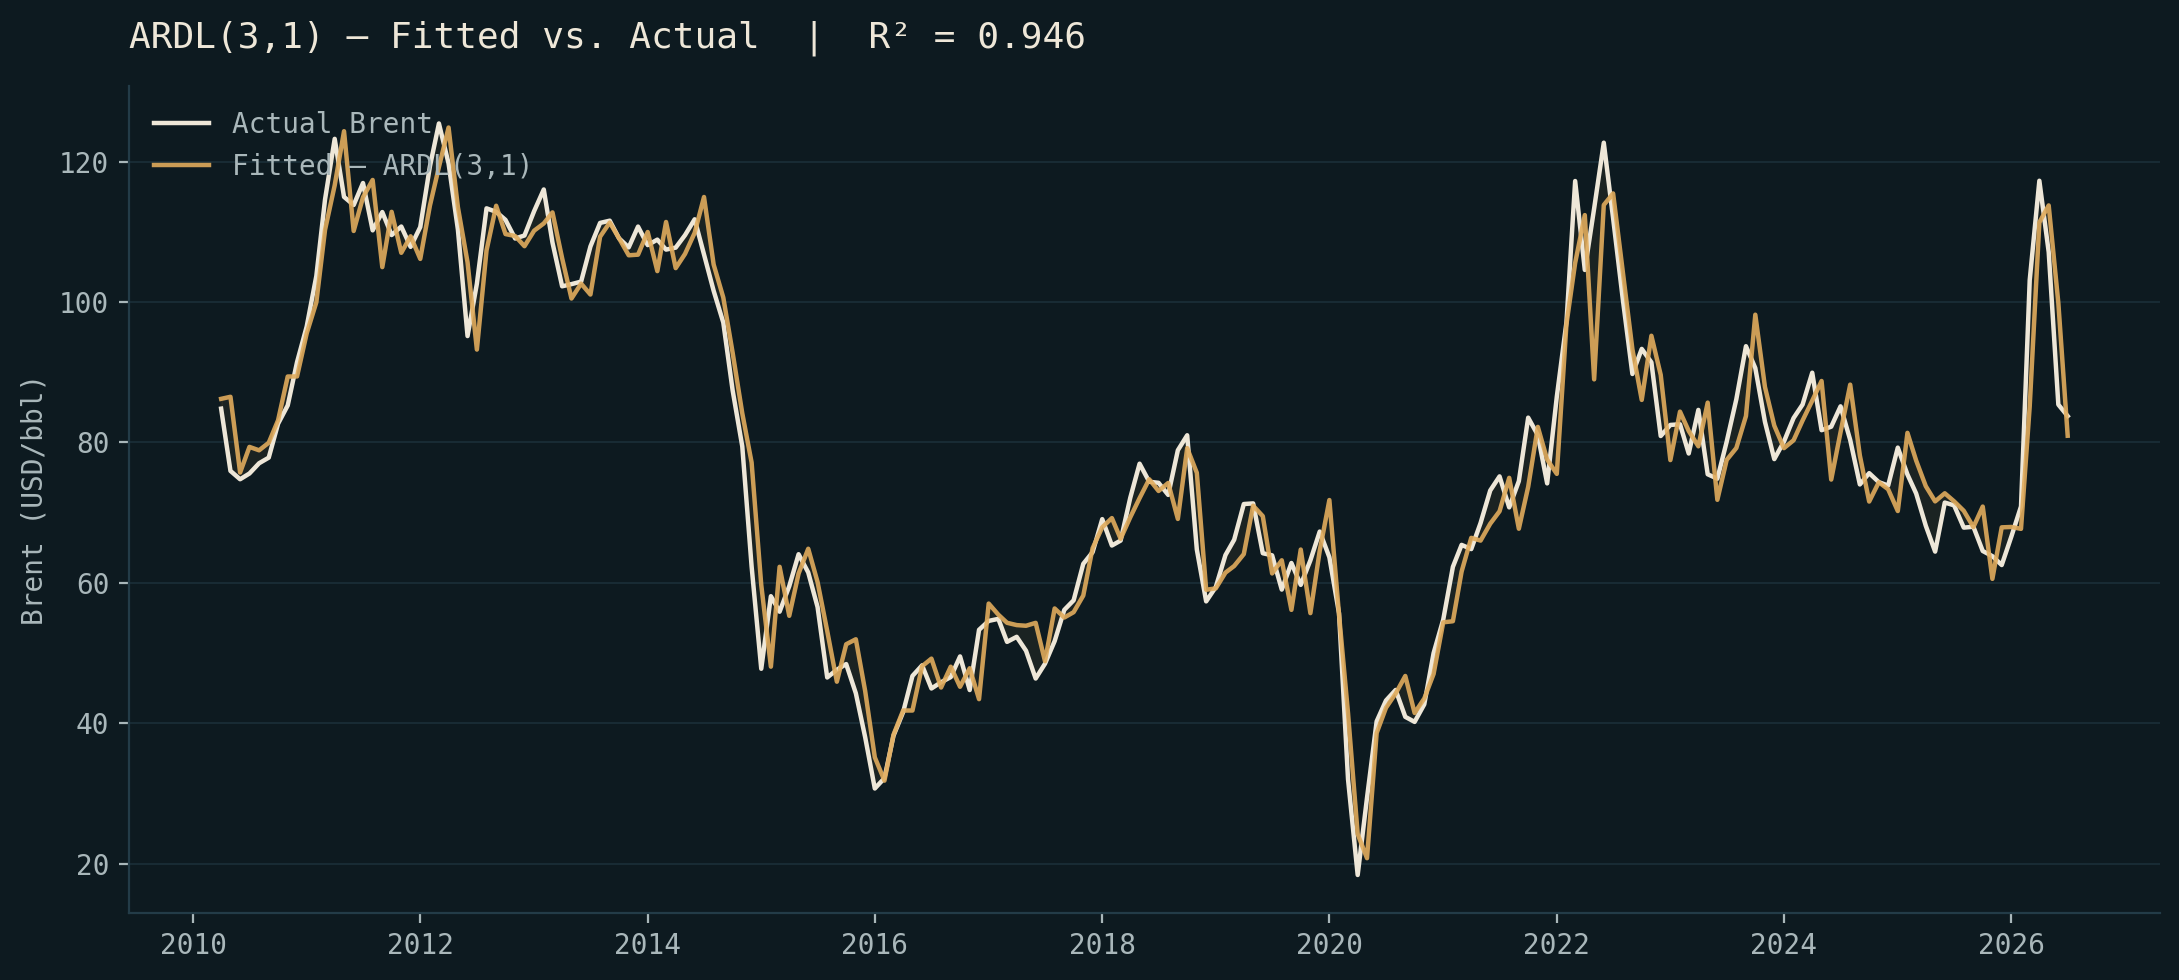

In [17]:
# export Fig 1 — fitted vs. actual Brent, ARDL(P,Q), styled to match the site

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

# --- reconstruct fitted values from residuals ---
fitted = y - resid

# --- get the date index aligned to y/resid ---

date_col = 'Date'  # <-- change this to match df.columns.tolist() output

dates = pd.to_datetime(df[date_col]).iloc[-len(y):].reset_index(drop=True)
assert len(dates) == len(y), f"length mismatch: dates={len(dates)}, y={len(y)}"

# --- site theme colors ---
INK        = "#0d1a20"
PAPER      = "#eee7d8"
PAPER_DIM  = "#a9b7ba"
AMBER      = "#c9903f"
AMBER_BR   = "#e0ab5c"
PANEL_LINE = "#233c48"

plt.rcParams.update({
    "font.family": "monospace",
    "text.color": PAPER,
    "axes.labelcolor": PAPER_DIM,
    "xtick.color": PAPER_DIM,
    "ytick.color": PAPER_DIM,
})

fig, ax = plt.subplots(figsize=(11, 5), dpi=200)
fig.patch.set_facecolor(INK)
ax.set_facecolor(INK)

ax.plot(dates, y, color=PAPER, linewidth=1.6, label="Actual Brent", zorder=3)
ax.plot(dates, fitted, color=AMBER_BR, linewidth=1.6, alpha=0.9,
        label=f"Fitted — ARDL({P},{Q})", zorder=4)

# shade the residual gap lightly for texture
ax.fill_between(dates, y, fitted, color=AMBER, alpha=0.08, zorder=1)

ax.set_title(f"ARDL({P},{Q}) — Fitted vs. Actual  |  R² = {stats_out.get('R2', stats_out.get('r2', float('nan'))):.3f}",
             color=PAPER, fontsize=13, loc="left", pad=14)
ax.set_ylabel("Brent (USD/bbl)")

for spine in ax.spines.values():
    spine.set_color(PANEL_LINE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color=PANEL_LINE, linewidth=0.6, alpha=0.6)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

legend = ax.legend(loc="upper left", frameon=False, fontsize=10)
for text in legend.get_texts():
    text.set_color(PAPER_DIM)

fig.tight_layout()

# --- export ---
out_dir = r'C:\Users\jiech\PycharmProjects\JupyterProject\crude-ardl-result'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "ardl-fit.png")

fig.savefig(out_path, facecolor=INK, bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     ------------------- ------------------ 20.5/40.8 kB 217.9 kB/s eta 0:00:01
     ---------------------------- --------- 30.7/40.8 kB 262.6 kB/s eta 0:00:01
     -------------------------------------- 40.8/40.8 kB 324.9 kB/s eta 0:00:00
Saved: C:\Users\jiech\PycharmProjects\JupyterProject\assets\charts\ardl-coefficients.png


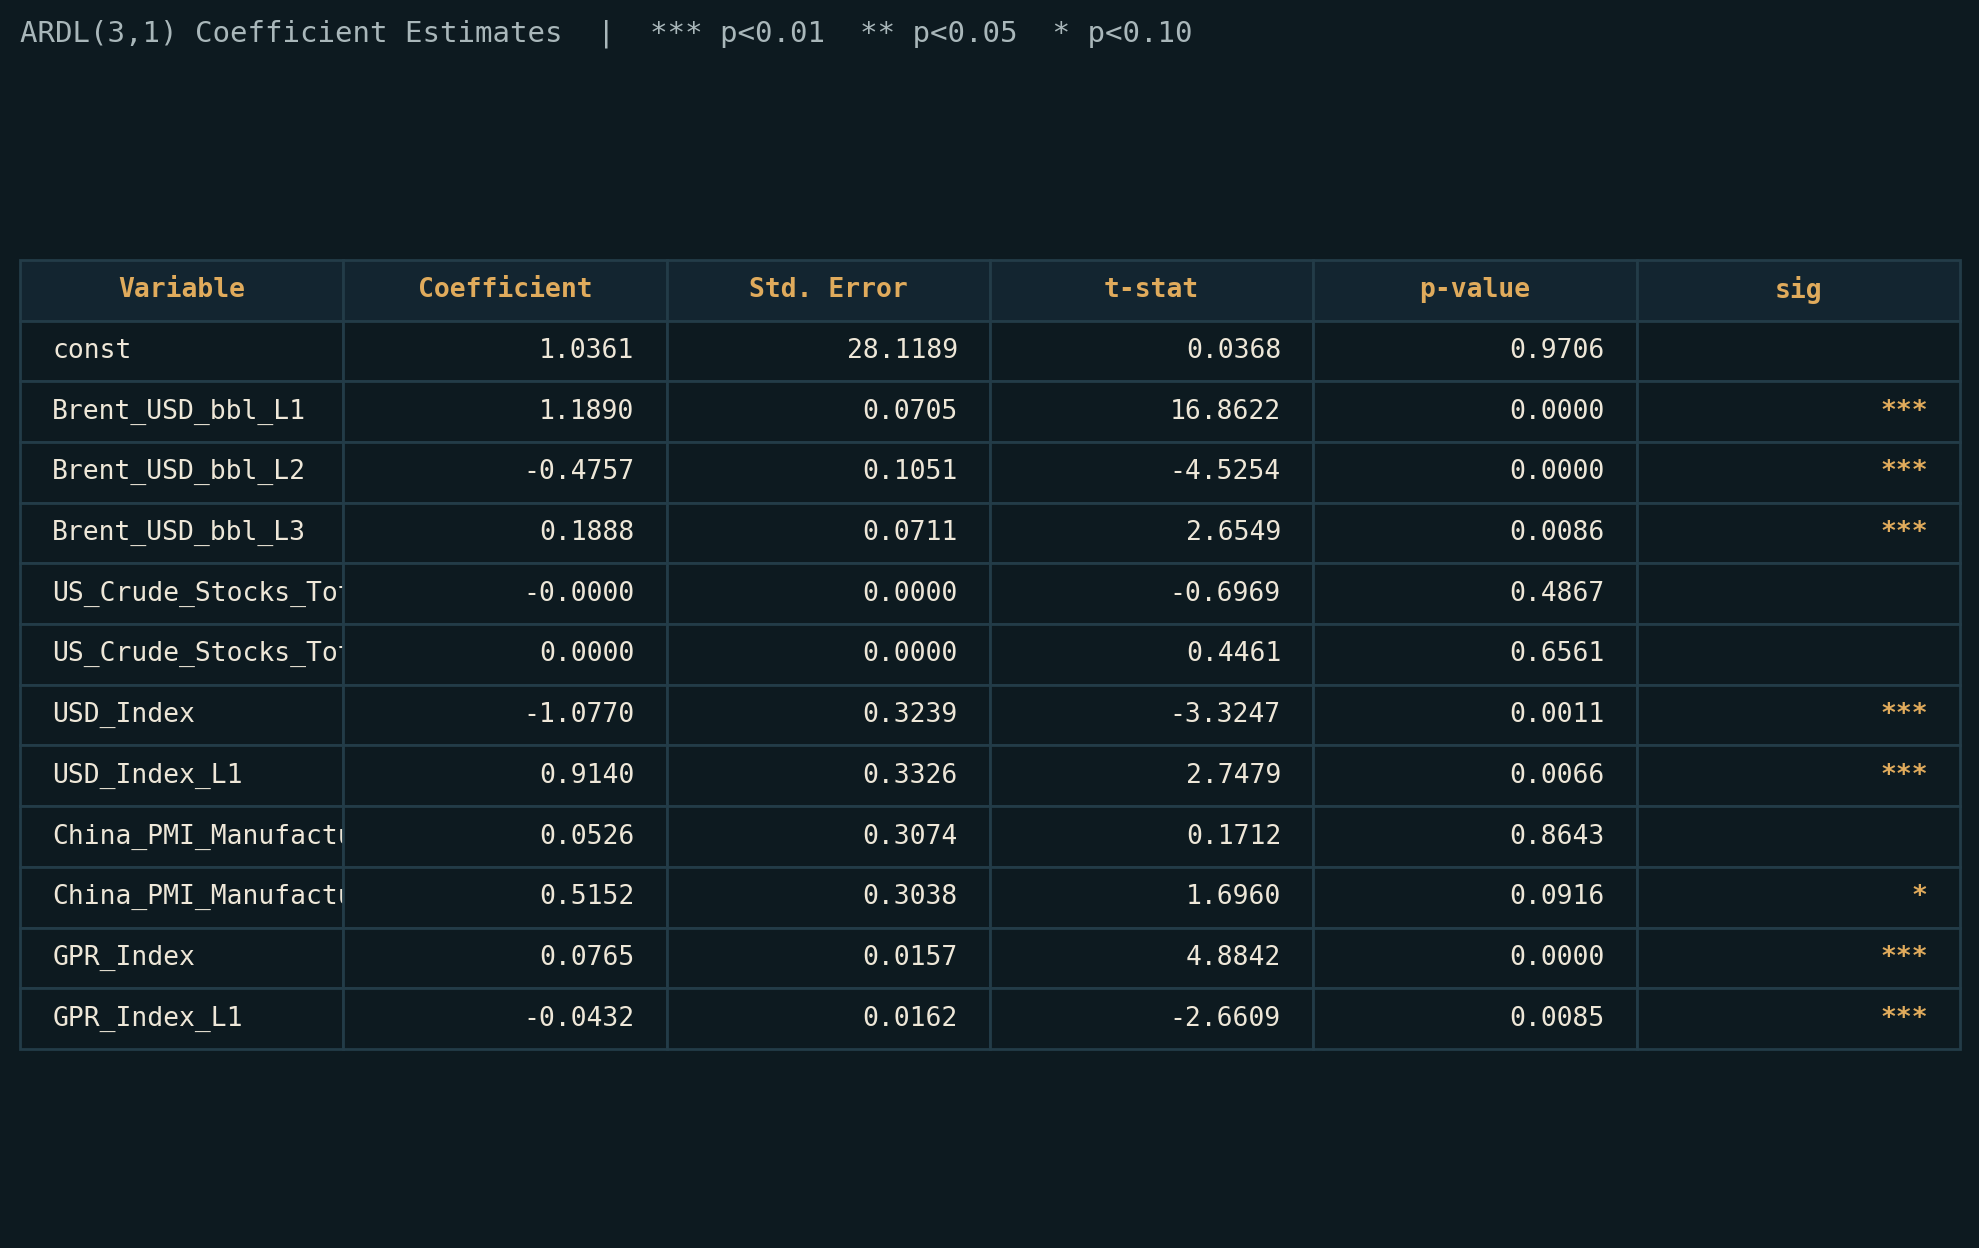

Saved markdown table: C:\Users\jiech\PycharmProjects\JupyterProject\ardl-coefficients.md


In [21]:
# export Table 1 — ARDL coefficient table, styled to match the site
import matplotlib.pyplot as plt
import pandas as pd
import os
!pip install tabulate

coef_df = table.copy()
coef_df.index.name = "Variable"
coef_df = coef_df.reset_index()

# rename to display labels
coef_df = coef_df.rename(columns={
    "coef": "Coefficient",
    "se": "Std. Error",
    "t": "t-stat",
    "p": "p-value",
})

# significance stars
def stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""
coef_df["sig"] = coef_df["p-value"].apply(stars)

# --- site theme colors ---
INK, PANEL, PANEL_LINE = "#0d1a20", "#132530", "#233c48"
PAPER, PAPER_DIM, AMBER_BR = "#eee7d8", "#a9b7ba", "#e0ab5c"

# formatted copy for display (raw coef_df kept for the markdown export)
fmt_df = coef_df.copy()
for col in ["Coefficient", "Std. Error", "t-stat"]:
    fmt_df[col] = fmt_df[col].map(lambda v: f"{v:.4f}")
fmt_df["p-value"] = fmt_df["p-value"].map(lambda v: f"{v:.4f}")

fig, ax = plt.subplots(figsize=(10, 0.42 * len(fmt_df) + 1.3), dpi=200)
fig.patch.set_facecolor(INK)
ax.axis("off")

tbl = ax.table(
    cellText=fmt_df.values,
    colLabels=fmt_df.columns,
    cellLoc="right",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.55)

n_cols = len(fmt_df.columns)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(PANEL_LINE)
    if row == 0:
        cell.set_facecolor(PANEL)
        cell.set_text_props(color=AMBER_BR, fontfamily="monospace", weight="bold")
    else:
        cell.set_facecolor(INK)
        cell.set_text_props(color=PAPER, fontfamily="monospace")
        if col == 0:  # variable name column, left-align
            cell.set_text_props(color=PAPER, fontfamily="monospace", ha="left")
        if col == n_cols - 1:  # sig stars column
            cell.set_text_props(color=AMBER_BR, fontfamily="monospace", weight="bold")

ax.set_title(f"ARDL({P},{Q}) Coefficient Estimates  |  *** p<0.01  ** p<0.05  * p<0.10",
             color=PAPER_DIM, fontsize=10.5, loc="left", pad=14, fontfamily="monospace")

fig.tight_layout()

out_dir = r'C:\Users\jiech\PycharmProjects\JupyterProject\assets\charts'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "ardl-coefficients.png")
fig.savefig(out_path, facecolor=INK, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

# --- also export as a Markdown table ---
md_out_dir = r'C:\Users\jiech\PycharmProjects\JupyterProject'
md_path = os.path.join(md_out_dir, "ardl-coefficients.md")
with open(md_path, "w") as f:
    f.write(coef_df.round(4).to_markdown(index=False))

In [ ]:
#long-run coefficient
ar_terms = [c for c in cols if c.startswith(f'{y_name}_L')]
sum_ar = table.loc[ar_terms, 'coef'].sum()
print("Sum of AR coefficients (persistence):", round(sum_ar, 4))

long_run = {}
for x in x_names:
    terms = [x] + [f'{x}_L{j}' for j in range(1, Q + 1)]
    terms = [t for t in terms if t in table.index]
    s = table.loc[terms, 'coef'].sum()
    long_run[x] = s / (1 - sum_ar)

lr_df = pd.DataFrame.from_dict(long_run, orient='index', columns=['long_run_coef'])
lr_df

In [ ]:
#ARDL bound test for cointegration
p, q = P, Q  # use the same order as the preferred ARDL model

d = df.copy()
for c in [y_name] + x_names:
    d[f'D_{c}'] = d[c].diff()

cols_ecm = {'const': 1.0, f'{y_name}_L1': d[y_name].shift(1)}
for x in x_names:
    cols_ecm[f'{x}_L1'] = d[x].shift(1)
for i in range(1, p):
    cols_ecm[f'D_{y_name}_L{i}'] = d[f'D_{y_name}'].shift(i)
for x in x_names:
    for j in range(0, q):
        lbl = f'D_{x}' if j == 0 else f'D_{x}_L{j}'
        cols_ecm[lbl] = d[f'D_{x}'].shift(j)

X_ecm = pd.DataFrame(cols_ecm)
dep = d[f'D_{y_name}']
full_ecm = pd.concat([dep, X_ecm], axis=1).dropna().reset_index(drop=True)
yv = full_ecm.iloc[:, 0].values
Xv = full_ecm.iloc[:, 1:].values
colnames_ecm = list(full_ecm.columns[1:])

ecm_table, ecm_stats, ecm_resid = ols_fit(yv, Xv, colnames_ecm)
print(ecm_table)

level_terms = [f'{y_name}_L1'] + [f'{x}_L1' for x in x_names]
idx_level = [colnames_ecm.index(t) for t in level_terms]
idx_other = [i for i in range(Xv.shape[1]) if i not in idx_level]

Xr = Xv[:, idx_other]
betar = np.linalg.inv(Xr.T @ Xr) @ Xr.T @ yv
residr = yv - Xr @ betar
ssr_r = residr @ residr
ssr_u = ecm_resid @ ecm_resid
n, k = Xv.shape
dof = n - k
q_restr = len(idx_level)

F_bounds = ((ssr_r - ssr_u) / q_restr) / (ssr_u / dof)
F_p = 1 - stats.f.cdf(F_bounds, q_restr, dof)
t_ec = ecm_table.loc[f'{y_name}_L1', 't']

print(f"\nBounds F-statistic: {F_bounds:.3f}  (df={q_restr},{dof}, p={F_p:.4f})")
print(f"Error-correction term t-stat (Brent_L1): {t_ec:.3f}")

print("\nCompare F-statistic against Pesaran-Shin-Smith (2001) Table CI (F-bounds),")
print("Case III (unrestricted intercept, no trend), k=4:")
print("  10%: I(0)=2.45  I(1)=3.52")
print("   5%: I(0)=2.86  I(1)=4.01")
print("   1%: I(0)=3.74  I(1)=5.06")

f_bounds_ci = {
    '10%': (2.45, 3.52),
    '5%':  (2.86, 4.01),
    '1%':  (3.74, 5.06),
}
for level, (i0, i1) in f_bounds_ci.items():
    if F_bounds > i1:
        verdict = "above I(1) bound -> supports cointegration"
    elif F_bounds < i0:
        verdict = "below I(0) bound -> no cointegration"
    else:
        verdict = "between bounds -> inconclusive"
    print(f"  {level}: F={F_bounds:.3f} vs I(0)={i0}, I(1)={i1}  ->  {verdict}")

print("\nCompare error-correction t-stat against Pesaran-Shin-Smith (2001) Table CII (t-bounds),")
print("Case III (unrestricted intercept, no trend), k=4:")
print("  10%: I(0)=-2.57  I(1)=-3.66")
print("   5%: I(0)=-2.86  I(1)=-3.99")
print(" 2.5%: I(0)=-3.13  I(1)=-4.26")
print("   1%: I(0)=-3.43  I(1)=-4.60")

t_bounds_ci = {
    '10%':  (-2.57, -3.66),
    '5%':   (-2.86, -3.99),
    '2.5%': (-3.13, -4.26),
    '1%':   (-3.43, -4.60),
}
for level, (i0, i1) in t_bounds_ci.items():
    if t_ec < i1:
        verdict = "below I(1) bound -> supports cointegration"
    elif t_ec > i0:
        verdict = "above I(0) bound -> no cointegration"
    else:
        verdict = "between bounds -> inconclusive"
    print(f"  {level}: t={t_ec:.3f} vs I(0)={i0}, I(1)={i1}  ->  {verdict}")



In [ ]:
date_col = 'Date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col).sort_index()

In [ ]:
#chow test
def chow_test(df, break_date, y_col, x_cols, p, q):
    y, X, dates = build_ardl_matrix(df, y_col, x_cols, p, q)
    dates = np.array(dates)
    break_date = pd.Timestamp(break_date)
    mask1 = dates < break_date
    mask2 = ~mask1

    _, _, rss_pooled = fit_ols(y, X)
    _, _, rss1 = fit_ols(y[mask1], X[mask1])
    _, _, rss2 = fit_ols(y[mask2], X[mask2])

    k = X.shape[1]
    n1, n2 = mask1.sum(), mask2.sum()

    F = ((rss_pooled - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n1 + n2 - 2*k))
    p_value = 1 - stats.f.cdf(F, k, n1 + n2 - 2*k)

    print(f"Break: {break_date.date()} | n1={n1}, n2={n2}, k={k}")
    print(f"F={F:.3f}, p={p_value:.4f}")
    return F, p_value

chow_test(df, '2020-02-01', 'Brent_USD_bbl', x_cols, p=3, q=1)
chow_test(df, '2022-02-01', 'Brent_USD_bbl', x_cols, p=3, q=1)

In [ ]:
#rolling-window regression
import pandas as pd
import matplotlib.pyplot as plt

y_col = 'Brent_USD_bbl'
x_cols = ['US_Crude_Stocks_Total_kbbl', 'USD_Index', 'China_PMI_Manufacturing', 'GPR_Index']
p, q = 3, 1

def rolling_ardl(df, y_col, x_cols, p, q, window=30, step=1):
    y_full, X_full, dates_full = build_ardl_matrix(df, y_col, x_cols, p, q)

    var_names = ['const'] + [f'{y_col}_L{i}' for i in range(1, p+1)]
    for x in x_cols:
        var_names.append(x)
        var_names += [f'{x}_L{i}' for i in range(1, q+1)]

    records = []
    for start in range(0, len(y_full) - window + 1, step):
        end = start + window
        beta, _, _ = fit_ols(y_full[start:end], X_full[start:end])
        rec = {'date': dates_full[end-1]}
        rec.update(dict(zip(var_names, beta)))
        records.append(rec)

    return pd.DataFrame(records).set_index('date')

roll = rolling_ardl(df, y_col, x_cols, p, q, window=30)

# Plot the contemporaneous coefficient for each driver (not the lags, to keep it readable)
fig, axes = plt.subplots(len(x_cols), 1, figsize=(10, 3*len(x_cols)), sharex=True)
for ax, x in zip(axes, x_cols):
    ax.plot(roll.index, roll[x], color='steelblue')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), color='red', alpha=0.15, label='COVID crash')
    ax.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-12-01'), color='orange', alpha=0.15, label='Russia-Ukraine / price cap')
    ax.set_title(f'Rolling coefficient (30mo window): {x}')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(r'C:\Users\jiech\PycharmProjects\JupyterProject\crude oil_rolling_coefficients.png', dpi=150)
plt.show()

In [ ]:
#forecasting
import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv('merged_monthly.csv', parse_dates=['Date'], index_col='Date')

# ARDL(3,1): y_t = c + sum_{i=1}^3 a_i*y_{t-i} + sum_j (b0_j*x_j,t + b1_j*x_j,t-1)
y_col = 'Brent_USD_bbl'
x_cols = ['US_Crude_Stocks_Total_kbbl', 'USD_Index', 'China_PMI_Manufacturing', 'GPR_Index']  # match your actual column names

def build_design(df, p=3, q=1):
    d = df.copy()
    for i in range(1, p+1):
        d[f'{y_col}_L{i}'] = d[y_col].shift(i)
    for x in x_cols:
        for j in range(0, q+1):
            d[f'{x}_L{j}'] = d[x].shift(j)
    d = d.dropna()
    y = d[y_col].values
    X_cols = [f'{y_col}_L{i}' for i in range(1, p+1)] + \
             [f'{x}_L{j}' for x in x_cols for j in range(0, q+1)]
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in X_cols])
    return d.index, y, X, X_cols

idx, y_full, X_full, colnames = build_design(df)

# --- Expanding-window walk-forward, 1-step ahead ---
test_start = '2024-01-01'
test_mask = idx >= test_start
test_idx = np.where(test_mask)[0]

ardl_preds, rw_preds, actuals = [], [], []

for t in test_idx:
    X_train, y_train = X_full[:t], y_full[:t]   # everything before t
    beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)

    x_t = X_full[t:t+1]
    ardl_pred = x_t @ beta
    rw_pred = y_full[t-1]          # random walk: yesterday's actual

    ardl_preds.append(ardl_pred[0])
    rw_preds.append(rw_pred)
    actuals.append(y_full[t])

ardl_preds, rw_preds, actuals = map(np.array, (ardl_preds, rw_preds, actuals))

# --- Metrics ---
def rmse(pred, act): return np.sqrt(np.mean((pred - act)**2))
def mae(pred, act): return np.mean(np.abs(pred - act))

print(f"ARDL  RMSE: {rmse(ardl_preds, actuals):.3f}  MAE: {mae(ardl_preds, actuals):.3f}")
print(f"RW    RMSE: {rmse(rw_preds, actuals):.3f}  MAE: {mae(rw_preds, actuals):.3f}")

# --- Diebold-Mariano test (squared error loss) ---
def diebold_mariano(e1, e2, h=1):
    d = e1**2 - e2**2
    d_mean = d.mean()
    n = len(d)
    # simple Newey-West variance, lag = h-1
    gamma0 = np.var(d, ddof=0)
    dm_stat = d_mean / np.sqrt(gamma0 / n)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

e_ardl = actuals - ardl_preds
e_rw = actuals - rw_preds
dm_stat, p_val = diebold_mariano(e_ardl, e_rw)
print(f"\nDiebold-Mariano stat: {dm_stat:.3f}, p-value: {p_val:.3f}")
print("Negative stat + p<0.05 → ARDL significantly beats RW")
print("Positive stat + p<0.05 → RW significantly beats ARDL")
print("p>0.05 → no significant difference")

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2.5, 1]})

test_dates = idx[test_mask]

# --- Top: actual vs predicted ---
ax = axes[0]
ax.plot(test_dates, actuals, label='Actual Brent', color='black', linewidth=1.8)
ax.plot(test_dates, ardl_preds, label='ARDL(3,1) forecast', color='#1f77b4', linewidth=1.4)
ax.plot(test_dates, rw_preds, label='Random walk forecast', color='#ff7f0e',
        linewidth=1.2, linestyle='--')
ax.set_ylabel('USD/bbl')
ax.set_title('Out-of-Sample Forecast: ARDL vs Random Walk (2024–2026)')
ax.legend(loc='best')
ax.grid(alpha=0.3)

# --- Bottom: forecast errors ---
ax2 = axes[1]
ax2.plot(test_dates, e_ardl, label='ARDL error', color='#1f77b4', linewidth=1.2)
ax2.plot(test_dates, e_rw, label='RW error', color='#ff7f0e', linewidth=1.2, linestyle='--')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Error (USD/bbl)')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ardl_vs_rw_forecast.png', dpi=150)
plt.show()

print(f"\nARDL error std: {e_ardl.std():.3f}")
print(f"RW error std:   {e_rw.std():.3f}")